In [15]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.interpolate import CubicSpline
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

In [16]:
DATA_PATH = r"C:\Users\kaija\Downloads\Nat_Gas.csv"

def load_data(path=DATA_PATH):
    df = pd.read_csv(path)
    df.columns = ["date", "price"]
    df["date"] = pd.to_datetime(df["date"], format="%m/%d/%y")
    df = df.sort_values("date").reset_index(drop=True)
    return df

In [17]:
def build_model(df):
    """
    Returns a callable price_fn(date) valid from first data point to
    one year beyond the last data point.

    Strategy:
      - Inside the data range: cubic spline interpolation.
      - Beyond the data range (up to +1 year): trend + seasonal model.
        * Linear trend fitted on full series.
        * Monthly seasonal factors from STL decomposition.
    """
    # Numeric days since epoch for spline
    t0 = df["date"].iloc[0]
    days = (df["date"] - t0).dt.days.values.astype(float)
    prices = df["price"].values.astype(float)

    spline = CubicSpline(days, prices, bc_type="not-a-knot")

    # Seasonal decomposition (additive, period=12 months)
    ts = df.set_index("date")["price"].asfreq("ME")  # month-end freq
    decomp = seasonal_decompose(ts, model="additive", period=12, extrapolate_trend="freq")

    seasonal = decomp.seasonal      # one full cycle of seasonal factors
    trend_comp = decomp.trend

    # Fit linear trend on the trend component (drop NaNs at edges)
    trend_clean = trend_comp.dropna()
    trend_days = ((trend_clean.index - t0).days).values.astype(float)
    trend_coeff = np.polyfit(trend_days, trend_clean.values, 1)  # slope, intercept

    # Monthly seasonal lookup (month number 1-12 → seasonal adjustment)
    monthly_seasonal = seasonal.groupby(seasonal.index.month).mean().to_dict()

    last_day = float((df["date"].iloc[-1] - t0).days)
    extrap_end = last_day + 365.25

    def price_fn(query_date):
        if isinstance(query_date, str):
            query_date = pd.to_datetime(query_date)
        d = float((query_date - t0).days)

        if d < 0:
            raise ValueError(f"Date {query_date.date()} is before the data start {t0.date()}")
        if d > extrap_end:
            raise ValueError(
                f"Date {query_date.date()} is more than 1 year beyond the data end "
                f"({df['date'].iloc[-1].date()}). Extrapolation not supported past that."
            )

        if d <= last_day:
            return float(spline(d))
        else:
            # Extrapolate: linear trend + seasonal factor
            trend_val = np.polyval(trend_coeff, d)
            seas_val = monthly_seasonal.get(query_date.month, 0.0)
            return float(trend_val + seas_val)

    return price_fn, t0, last_day, extrap_end, trend_coeff, monthly_seasonal, t0

In [18]:

_df = load_data()
_price_fn, _t0, _last_day, _extrap_end, _trend_coeff, _monthly_seasonal, _origin = build_model(_df)

def get_price(date_input):
    """
    Return estimated natural gas purchase price for a given date.

    Parameters
    ----------
    date_input : str or datetime-like
        Any date from 2020-10-31 to ~2025-09-30 (one year beyond data end).

    Returns
    -------
    float : estimated price (same units as source data, USD/MMBtu)
    """
    price = _price_fn(date_input)
    return round(price, 4)

In [19]:
def plot_analysis():
    df = _df.copy()

    # Build dense grid for smooth curves
    all_days = np.linspace(0, _extrap_end, 800)
    all_dates = [_t0 + timedelta(days=float(d)) for d in all_days]
    hist_mask = all_days <= _last_day
    extrap_mask = all_days >= _last_day

    hist_dates  = [d for d, m in zip(all_dates, hist_mask) if m]
    hist_prices = [_price_fn(d) for d in hist_dates]
    ext_dates   = [d for d, m in zip(all_dates, extrap_mask) if m]
    ext_prices  = [_price_fn(d) for d in ext_dates]

    # Seasonal bar chart
    months = list(range(1, 13))
    seas_vals = [_monthly_seasonal.get(m, 0) for m in months]
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

    # ── Graph 1: Raw data + spline + extrapolation ───────────────────────────
    fig1, ax1 = plt.subplots(figsize=(13, 5))
    ax1.scatter(df["date"], df["price"], color="#1f4e79", zorder=5, s=55,
                label="Monthly data points", edgecolors="white", linewidths=0.6)
    ax1.plot(hist_dates, hist_prices, color="#2e86de", linewidth=2,
             label="Cubic spline (interpolation)")
    ax1.plot(ext_dates, ext_prices, color="#e84118", linewidth=2, linestyle="--",
             label="Trend + seasonal (extrapolation)")
    ax1.axvline(df["date"].iloc[-1], color="gray", linestyle=":", linewidth=1.2, label="Data end")
    ax1.set_title("Price History & 12-Month Forecast", fontsize=12)
    ax1.set_ylabel("Price (USD/MMBtu)")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Graph 2: Seasonal pattern ─────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(13, 5))
    colors = ["#e84118" if v > 0 else "#2e86de" for v in seas_vals]
    bars = ax2.bar(month_labels, seas_vals, color=colors, edgecolor="white", linewidth=0.8)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_title("Average Seasonal Price Deviation by Month", fontsize=12)
    ax2.set_ylabel("Seasonal Component (USD/MMBtu)")
    ax2.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, seas_vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, val + (0.003 if val >= 0 else -0.006),
                 f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Graph 3: Year-over-year comparison ───────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(13, 5))
    df["month"] = df["date"].dt.month
    df["year"]  = df["date"].dt.year
    pivot = df.pivot_table(index="month", columns="year", values="price")
    for yr in pivot.columns:
        ax3.plot(month_labels[:len(pivot[yr].dropna())],
                 pivot[yr].dropna().values,
                 marker="o", markersize=5, label=str(yr), linewidth=1.8)
    ax3.set_title("Year-over-Year Monthly Prices", fontsize=12)
    ax3.set_ylabel("Price (USD/MMBtu)")
    ax3.legend(title="Year", fontsize=9)
    ax3.grid(alpha=0.3)
    plt.tight_layout()
    out = r"C:\Users\kaija\quant research\nat_gas_analysis.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nPlot saved to: {out}")

  Natural Gas Price Estimator
  Data: Oct 2020 – Sep 2024 | Extrap: +1 year
  2021-06-15  ->  $9.8749  (interpolated)
  2022-12-31  ->  $11.6000  (interpolated)
  2023-08-10  ->  $11.3475  (interpolated)
  2024-09-30  ->  $11.8000  (interpolated)
  2024-11-15  ->  $12.7476  (extrapolated)
  2025-03-01  ->  $13.1968  (extrapolated)
  2025-09-28  ->  $12.5099  (extrapolated)

Generating analysis plots...


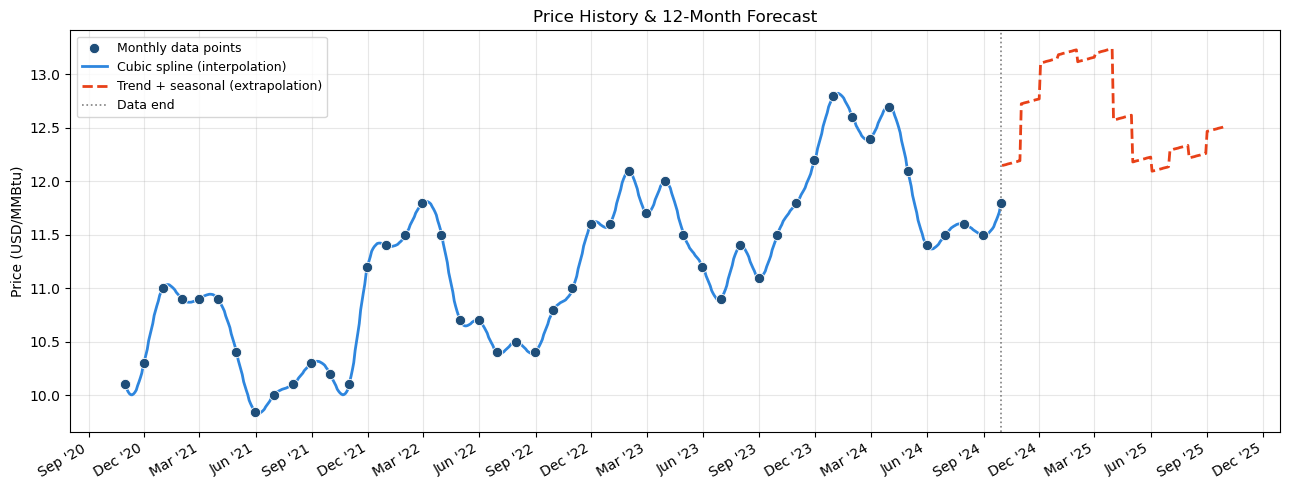

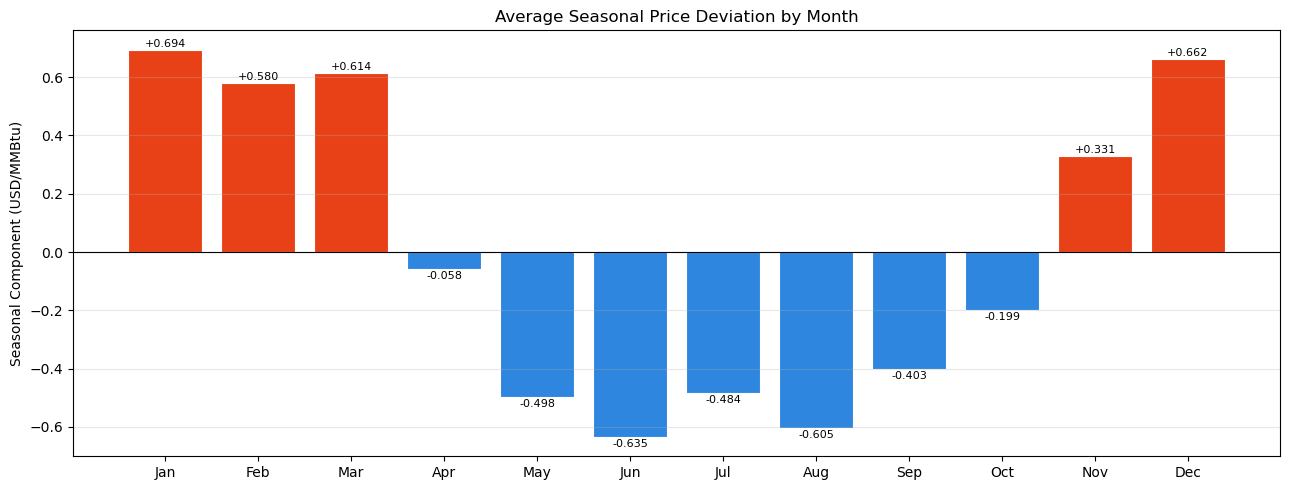

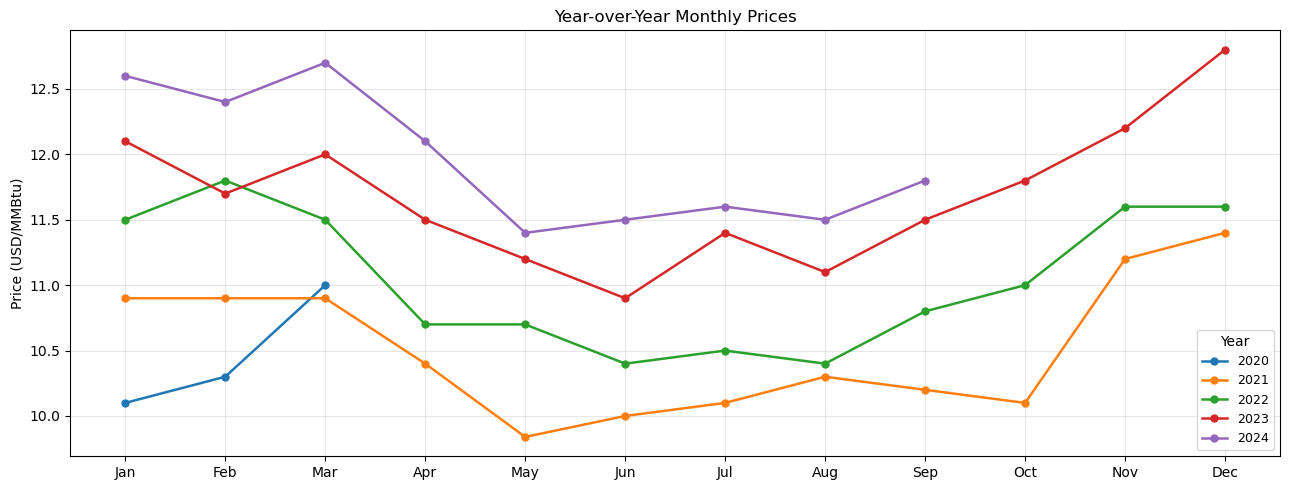


Plot saved to: C:\Users\kaija\quant research\nat_gas_analysis.png


In [20]:
if __name__ == "__main__":
    print("=" * 55)
    print("  Natural Gas Price Estimator")
    print("  Data: Oct 2020 – Sep 2024 | Extrap: +1 year")
    print("=" * 55)

    test_dates = [
        "2021-06-15",
        "2022-12-31",
        "2023-08-10",
        "2024-09-30",
        "2024-11-15",
        "2025-03-01",
        "2025-09-28",
    ]

    for d in test_dates:
        try:
            p = get_price(d)
            label = "(extrapolated)" if pd.to_datetime(d) > _df["date"].iloc[-1] else "(interpolated)"
            print(f"  {d}  ->  ${p:.4f}  {label}")
        except ValueError as e:
            print(f"  {d}  ->  ERROR: {e}")

    print("\nGenerating analysis plots...")
    plot_analysis()

In [21]:
import ipywidgets as widgets
from IPython.display import display

date_input = widgets.Text(
    placeholder="YYYY-MM-DD",
    description="Date:",
    layout=widgets.Layout(width="250px")
)
output = widgets.Output()

def on_submit(change):
    output.clear_output()
    with output:
        val = date_input.value.strip()
        if not val:
            return
        try:
            price = get_price(val)
            dt = pd.to_datetime(val)
            label = "extrapolated" if dt > _df["date"].iloc[-1] else "interpolated"
            print(f"  ${price:.4f} USD/MMBtu  ({label})")
        except Exception as e:
            print(f"  Error: {e}")

date_input.observe(on_submit, names="value")
display(widgets.VBox([date_input, output]))

17:41:33 - cmdstanpy - INFO - Chain [1] start processing
17:41:33 - cmdstanpy - INFO - Chain [1] done processing


Model trained on 48 monthly data points.
Forecast runs from 2024-09-30 → 2027-09-01  (36 months out)



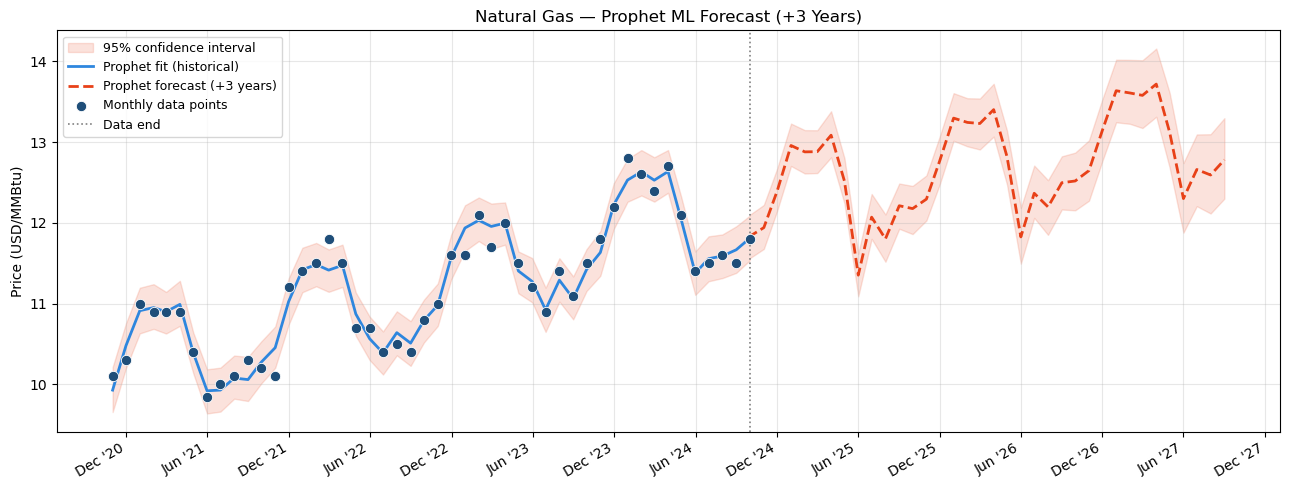

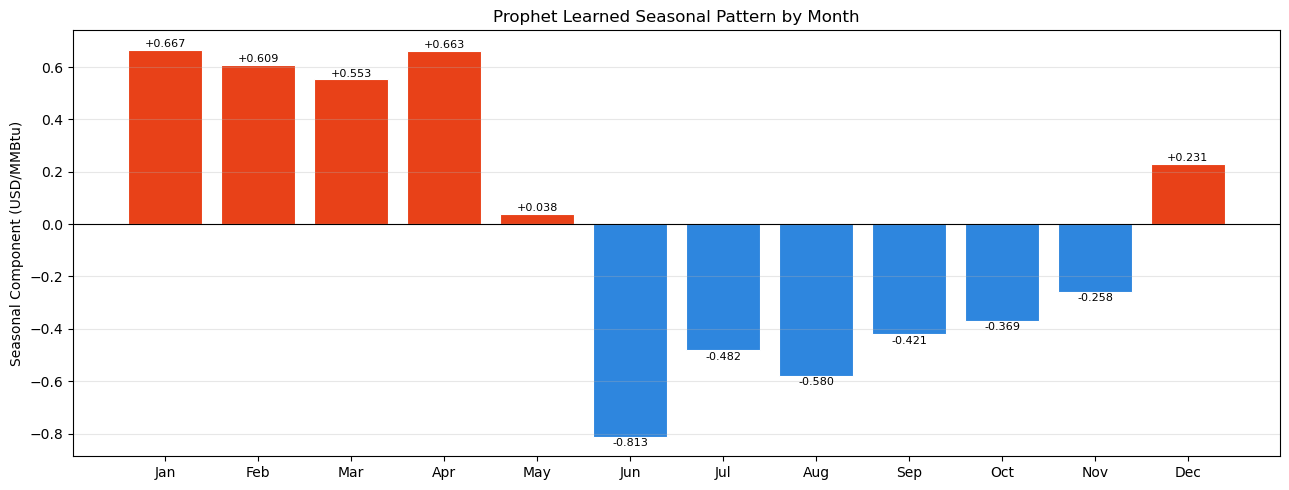

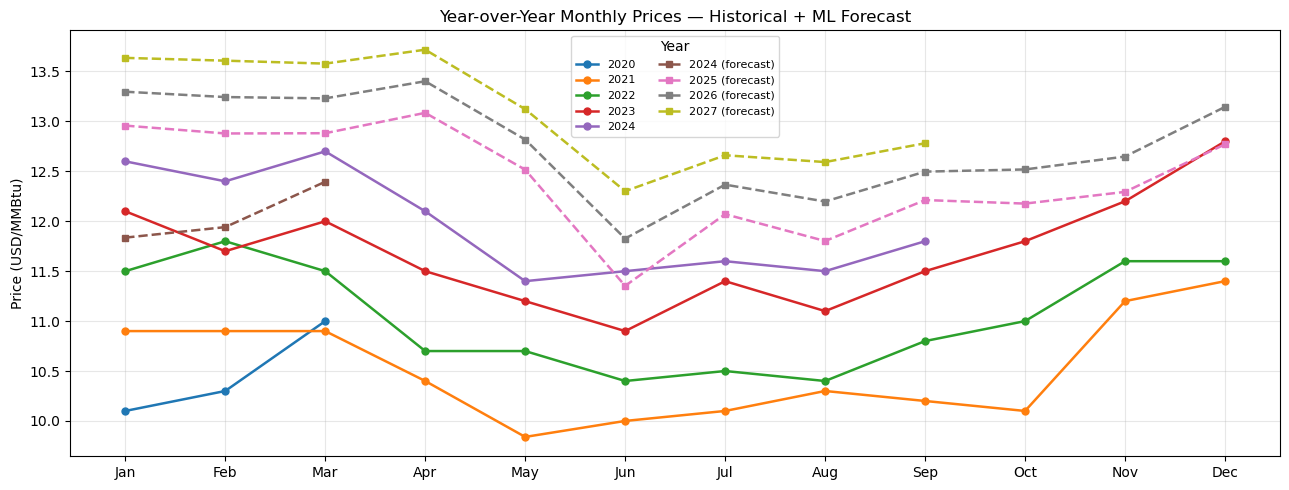

In [22]:
# pip install prophet   (run this in a terminal if you haven't already)
try:
    from prophet import Prophet
except ImportError:
    raise ImportError("Install Prophet first: pip install prophet")

FORECAST_MONTHS = 36  # how many months beyond the data to forecast

# ── Train ────────────────────────────────────────────────────────────────────
df_ml = _df.rename(columns={"date": "ds", "price": "y"})

ml_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95,
    changepoint_prior_scale=0.05,   # how flexible the trend is; higher = more wiggly
)
ml_model.fit(df_ml)

future = ml_model.make_future_dataframe(periods=FORECAST_MONTHS, freq="MS")
forecast = ml_model.predict(future)
hist_end = _df["date"].iloc[-1]
forecast_end = forecast["ds"].iloc[-1]

print(f"Model trained on {len(df_ml)} monthly data points.")
print(f"Forecast runs from {hist_end.date()} → {forecast_end.date()}  ({FORECAST_MONTHS} months out)\n")

# ── Price lookup function ─────────────────────────────────────────────────────
def get_ml_price(date_input):
    """Returns (price, lower_95, upper_95) for any date."""
    if isinstance(date_input, str):
        date_input = pd.to_datetime(date_input)
    if date_input < _df["date"].iloc[0]:
        raise ValueError(f"{date_input.date()} is before the training data starts.")
    if date_input > forecast_end:
        raise ValueError(f"{date_input.date()} is beyond the forecast horizon ({forecast_end.date()}).")
    pred = ml_model.predict(pd.DataFrame({"ds": [date_input]}))
    return (
        round(float(pred["yhat"].iloc[0]), 4),
        round(float(pred["yhat_lower"].iloc[0]), 4),
        round(float(pred["yhat_upper"].iloc[0]), 4),
    )

# ── Visualizations ────────────────────────────────────────────────────────────
def plot_ml_analysis():
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

    # ── Graph 1: Full forecast with confidence band ───────────────────────────
    fig1, ax1 = plt.subplots(figsize=(13, 5))
    hist_fc  = forecast[forecast["ds"] <= hist_end]
    fut_fc   = forecast[forecast["ds"] >= hist_end]

    ax1.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                     alpha=0.15, color="#e84118", label="95% confidence interval")
    ax1.plot(hist_fc["ds"], hist_fc["yhat"], color="#2e86de", linewidth=2,
             label="Prophet fit (historical)")
    ax1.plot(fut_fc["ds"], fut_fc["yhat"], color="#e84118", linewidth=2,
             linestyle="--", label=f"Prophet forecast (+{FORECAST_MONTHS//12} years)")
    ax1.scatter(_df["date"], _df["price"], color="#1f4e79", zorder=5, s=55,
                label="Monthly data points", edgecolors="white", linewidths=0.6)
    ax1.axvline(hist_end, color="gray", linestyle=":", linewidth=1.2, label="Data end")
    ax1.set_title(f"Natural Gas — Prophet ML Forecast (+{FORECAST_MONTHS//12} Years)", fontsize=12)
    ax1.set_ylabel("Price (USD/MMBtu)")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Graph 2: Seasonal component learned by Prophet ────────────────────────
    seasonal_sample = ml_model.predict(
        pd.DataFrame({"ds": pd.date_range("2023-01-01", periods=12, freq="MS")})
    )
    seas_vals = seasonal_sample["yearly"].values

    fig2, ax2 = plt.subplots(figsize=(13, 5))
    colors = ["#e84118" if v > 0 else "#2e86de" for v in seas_vals]
    bars = ax2.bar(month_labels, seas_vals, color=colors, edgecolor="white", linewidth=0.8)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_title("Prophet Learned Seasonal Pattern by Month", fontsize=12)
    ax2.set_ylabel("Seasonal Component (USD/MMBtu)")
    ax2.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, seas_vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, val + (0.003 if val >= 0 else -0.006),
                 f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Graph 3: Year-over-year (historical + forecasted years) ──────────────
    fig3, ax3 = plt.subplots(figsize=(13, 5))

    df_hist = _df.copy()
    df_hist["month"] = df_hist["date"].dt.month
    df_hist["year"]  = df_hist["date"].dt.year
    pivot = df_hist.pivot_table(index="month", columns="year", values="price")
    for yr in pivot.columns:
        data = pivot[yr].dropna()
        ax3.plot(month_labels[:len(data)], data.values,
                 marker="o", markersize=5, label=str(yr), linewidth=1.8)

    fut_only = forecast[forecast["ds"] > hist_end].copy()
    fut_only["month"] = fut_only["ds"].dt.month
    fut_only["year"]  = fut_only["ds"].dt.year
    fut_pivot = fut_only.pivot_table(index="month", columns="year", values="yhat")
    for yr in fut_pivot.columns:
        data = fut_pivot[yr].dropna()
        ax3.plot(month_labels[:len(data)], data.values,
                 marker="s", markersize=5, label=f"{yr} (forecast)",
                 linewidth=1.8, linestyle="--")

    ax3.set_title("Year-over-Year Monthly Prices — Historical + ML Forecast", fontsize=12)
    ax3.set_ylabel("Price (USD/MMBtu)")
    ax3.legend(title="Year", fontsize=8, ncol=2)
    ax3.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_ml_analysis()

In [23]:
import ipywidgets as widgets
from IPython.display import display

ml_date_input = widgets.Text(
    placeholder="YYYY-MM-DD",
    description="Date:",
    layout=widgets.Layout(width="250px")
)
ml_output = widgets.Output()

def on_ml_submit(change):
    ml_output.clear_output()
    with ml_output:
        val = ml_date_input.value.strip()
        if not val:
            return
        try:
            price, lower, upper = get_ml_price(val)
            dt = pd.to_datetime(val)
            label = "forecast" if dt > _df["date"].iloc[-1] else "historical fit"
            print(f"  Estimated price : ${price:.4f} USD/MMBtu  ({label})")
            print(f"  95% conf. range : ${lower:.4f} – ${upper:.4f}")
        except Exception as e:
            print(f"  Error: {e}")

ml_date_input.observe(on_ml_submit, names="value")
display(widgets.VBox([ml_date_input, ml_output]))